# Reference Wavefront: FAM Make Table

**Author:** Aaron Roodman  
**Date Created:** 2026-02-23  
**Last Modified:** 2026-03-15  
**Status:** [In Progress]  
**Keywords:** [AOS, Intrinsic Wavefront, Full Array Mode, Zernikes, Table]

## Description

This notebook creates a comprehensive table of Zernike wavefront measurements from Rubin Full Array Mode (FAM) cwfs images with model intrinsic values.

**Key functionality:**
1. Generate model intrinsic wavefront maps across the focal plane for each Zernike term
2. Identify FAM observations by test block program (e.g., T278, T381, T492, T539, T614)
3. Extract Zernike measurements from Butler for identified observations
4. Calculate per-visit mean Zernikes in configurable coordinate system (OCS or CCS)
5. Interpolate model intrinsic values at each donut position using field angles
6. Calculate residuals (data - model) for comparison
7. Determine rotator angles from ConsDB `physical_rotator_angle` and calculated fallback
8. Save comprehensive table to parquet file for analysis

**Output:** Parquet file with all Zernike data, ready for analysis in companion notebook

**Based on:**
- `reference_wavefront_FAM_study.ipynb`: Zernike wavefront extraction and intrinsic model
- `locate_test_blocks.ipynb`: Isolating Full Array Mode data by day_obs and seq_num
- LSSTCam AOS Datasets: https://rubinobs.atlassian.net/wiki/spaces/LTS/pages/761397307/LSSTCam+AOS+Datasets

<a id='changelog'></a>
## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-02-23 | Aaron Roodman | Initial version |
| 2026-03-13 | Aaron Roodman | Added parameter sets, rotator check |
| 2026-03-15 | Aaron Roodman | Added OCS/CCS parameter, revised rotator angle using ConsDB physical_rotator_angle and calculated fallback, output to output/ subdirectory |

## Table of Contents

- [Change Log](#changelog)
- [Parameters](#params)
- [Setup & Imports](#setup)
- [Helper Functions](#functions)
- [Model Intrinsic Wavefront](#intrinsic)
- [Identify FAM Data](#identify)
- [Rotator Angles](#rotator)
- [Extract Zernikes](#extract)
- [Add Model and Rotator Angles to Data](#model)
- [Results Table](#results)

<a id='params'></a>
## Parameters

All configurable parameters are collected here. Select `PARAM_SET` to choose which dataset to process.

In [ ]:
# ============================================================
# SELECT WHICH PARAMETER SET TO USE
# ============================================================
# Set to 1 for the original dataset, or 2 for the new dataset
PARAM_SET = 2

# ============================================================
# Coordinate system: 'OCS' or 'CCS'
# ============================================================
COORD_SYS = 'OCS'

# ============================================================
# Parameter Set 1: Original (Aug-Oct 2025)
# ============================================================
PARAMS_1 = dict(
    day_obs_min = 20250801,
    day_obs_max = 20251028,
    fam_programs = ['T278', 'T381', 'T492', 'T539', 'T614'],
    fam_collections = [
        'u/brycek/aos_fam_danish/wep_v15_0_2/donut_viz_v2_5_0/20250801_20250831',
        'u/brycek/aos_fam_danish/wep_v15_0_2/donut_viz_v2_5_0/20250901_20251028',
    ],
)

# ============================================================
# Parameter Set 2: New (Oct-Dec 2025)
# See: https://rubinobs.atlassian.net/wiki/spaces/LTS/pages/761397307/LSSTCam+AOS+Datasets
# ============================================================
PARAMS_2 = dict(
    day_obs_min = 20251020,
    day_obs_max = 20251231,
    fam_programs = ['T278', 'T381', 'T492', 'T539', 'T614'],
    fam_collections = [
        'u/brycek/aos_fam_danish_step2/wep_v16_5_0/donut_viz_v3_2_3/20251020_20251231',
    ],
)

# ============================================================
# Common parameters
# ============================================================
ROTATOR_ANGLE_THRESHOLD = 3.0  # degrees from zero
INTRINSIC_BAND = None  # will be set after imports (BandLabel.LSST_I)
FP_RADIUS = 1.8  # degrees (edge of focal plane)
FP_NSTEPS = 73  # 18*4 + 1 grid points per axis

# ============================================================
# Output
# ============================================================
output_dir = 'output'

# ============================================================
# Resolve active parameters
# ============================================================
if PARAM_SET == 1:
    PARAMS = PARAMS_1
elif PARAM_SET == 2:
    PARAMS = PARAMS_2
else:
    raise ValueError(f"Unknown PARAM_SET: {PARAM_SET}")

day_obs_min = PARAMS['day_obs_min']
day_obs_max = PARAMS['day_obs_max']
fam_programs = PARAMS['fam_programs']
fam_collections = PARAMS['fam_collections']

output_file = f'{output_dir}/fam_zernikes_{day_obs_min}_{day_obs_max}.parquet'

# Derived column names based on coordinate system choice
thx_col = f'thx_{COORD_SYS}'
thy_col = f'thy_{COORD_SYS}'
zk_col = f'zk_{COORD_SYS}'
zk_mean_col = f'zk_{COORD_SYS}_mean'

print(f"Active parameter set: {PARAM_SET}")
print(f"  Coordinate system: {COORD_SYS}")
print(f"  day_obs range: {day_obs_min} - {day_obs_max}")
print(f"  Programs: {fam_programs}")
print(f"  Collections: {fam_collections}")
print(f"  Output file: {output_file}")
print(f"  Rotator angle threshold: {ROTATOR_ANGLE_THRESHOLD} deg")

<a id='setup'></a>
## Setup & Imports

In [ ]:
# Standard imports
import sys
from matplotlib import pyplot as plt
from matplotlib import lines
from mpl_toolkits import axes_grid1
from matplotlib.colors import LinearSegmentedColormap

import numpy as np
import pandas as pd
from scipy.stats import binned_statistic_2d, binned_statistic
from scipy.interpolate import LinearNDInterpolator
from datetime import datetime
from pathlib import Path
import re
import os

# Astropy
from astropy.table import Table, QTable, vstack
from astropy.io import fits
from astropy.time import Time, TimeDelta

# LSST packages
from lsst.daf.butler import Butler, DatasetNotFoundError
import lsst.afw.cameraGeom as cameraGeom
import lsst.geom as geom
from lsst.obs.lsst import LsstCam
from lsst.ts.wep.task.estimateZernikesDanishTask import EstimateZernikesDanishTask
from lsst.ts.wep.task.donutStamps import DonutStamps
from lsst.ts.wep.task import CalcZernikesTask, CalcZernikesTaskConfig
from lsst.ts.wep.utils import getTaskInstrument, BandLabel
from lsst.ts.wep.estimation import WfEstimator
from lsst.summit.utils import ConsDbClient

# Progress bar
from tqdm import tqdm

# Local utilities
sys.path.insert(0, 'code')
from wcsutils import calc_rotator_angle

# Camera setup
camera = LsstCam.getCamera()
camera_id_map = camera.getIdMap()

# ConsDB setup
os.environ["no_proxy"] += ",.consdb"
client = ConsDbClient("http://consdb-pq.consdb:8080/consdb")

# Set the intrinsic band now that BandLabel is imported
INTRINSIC_BAND = BandLabel.LSST_I

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

<a id='functions'></a>
## Helper Functions

In [3]:
def infer_zernike_indices(nZk):
    """
    Infer the list of Noll Zernike indices present in the data
    based on the number of Zernike terms per donut.

    The WEP pipeline stores a subset of Noll indices starting at Z4.
    Different pipeline versions may include different ranges.

    Parameters
    ----------
    nZk : int
        Number of Zernike terms per donut measurement.

    Returns
    -------
    iZs : list of int
        Noll indices corresponding to each column.
    """
    if nZk == 25:
        # Z4 through Z28 (all)
        return list(range(4, 29))
    elif nZk == 21:
        # Z4-Z19 + Z22-Z26 (skipping Z20, Z21)
        return list(range(4, 20)) + list(range(22, 27))
    elif nZk == 19:
        # Z4 through Z22 (contiguous)
        return list(range(4, 23))
    else:
        # Fallback: assume contiguous from Z4
        iZs = list(range(4, 4 + nZk))
        print(f"Warning: Unexpected number of Zernike terms ({nZk}), "
              f"assuming Z4-Z{3 + nZk}")
        return iZs

In [4]:
def pixel_to_focal(x, y, det):
    """
    Convert pixel coordinates to focal plane coordinates.
    
    Parameters
    ----------
    x, y : array
        Pixel coordinates
    det : lsst.afw.cameraGeom.Detector
        Detector of interest

    Returns
    -------
    fpx, fpy : array
        Focal plane position in millimeters in DVCS (see LSE-349)
    """
    tx = det.getTransform(cameraGeom.PIXELS, cameraGeom.FOCAL_PLANE)
    fpx, fpy = tx.getMapping().applyForward(np.vstack((x, y)))
    return fpx.ravel(), fpy.ravel()

In [ ]:
def get_aggregate_zernikes(butler, day_obs, seq_num):
    """
    Get aggregate Zernike table for a single visit.

    Uses the coordinate system specified by the global COORD_SYS parameter.
    """
    try:
        aosTable = butler.get('aggregateAOSVisitTableRaw', day_obs=day_obs, seq_num=seq_num)
    except DatasetNotFoundError:
        print(f"DatasetNotFoundError: No data for day_obs={day_obs}, seq_num={seq_num}")
        return None
    except Exception as e:
        error_type = type(e).__name__
        if error_type == 'DimensionValueError':
            print(f"DimensionValueError for day_obs={day_obs}, seq_num={seq_num}")
        else:
            print(f"{error_type} for day_obs={day_obs}, seq_num={seq_num}: {e}")
        return None

    aosTable.meta = {}
    
    select = (aosTable['used'] == True)
    aosTable_sel = aosTable[select]

    if len(aosTable_sel) == 0:
        print(f"Warning: No 'used' donuts found for day_obs={day_obs}, seq_num={seq_num}")
        return None

    aosTable_sel['seq_num'] = seq_num
    aosTable_sel['day_obs'] = day_obs

    nstars = len(aosTable_sel)
    intra_fpx = np.zeros(nstars)
    intra_fpy = np.zeros(nstars)
    extra_fpx = np.zeros(nstars)
    extra_fpy = np.zeros(nstars)
    
    for detector in camera:
        selone = (aosTable_sel['detector'] == detector.getName())
        if not np.any(selone):
            continue
            
        x_one = aosTable_sel[selone]['centroid_x_intra']
        y_one = aosTable_sel[selone]['centroid_y_intra']
        fpx_one, fpy_one = pixel_to_focal(x_one, y_one, detector)
        intra_fpx[selone] = fpx_one
        intra_fpy[selone] = fpy_one
        
        x_one = aosTable_sel[selone]['centroid_x_extra']
        y_one = aosTable_sel[selone]['centroid_y_extra']
        fpx_one, fpy_one = pixel_to_focal(x_one, y_one, detector)
        extra_fpx[selone] = fpx_one
        extra_fpy[selone] = fpy_one

    aosTable_sel['intra_fpx'] = intra_fpx
    aosTable_sel['intra_fpy'] = intra_fpy
    aosTable_sel['extra_fpx'] = extra_fpx
    aosTable_sel['extra_fpy'] = extra_fpy

    # Use parameterized coordinate system column names
    thx_intra_col = f'thx_{COORD_SYS}_intra'
    thx_extra_col = f'thx_{COORD_SYS}_extra'
    thy_intra_col = f'thy_{COORD_SYS}_intra'
    thy_extra_col = f'thy_{COORD_SYS}_extra'

    thx_diff = np.abs(aosTable_sel[thx_intra_col] - aosTable_sel[thx_extra_col]) * 206265
    thy_diff = np.abs(aosTable_sel[thy_intra_col] - aosTable_sel[thy_extra_col]) * 206265
    matched_intra_extra = (thx_diff < 100.0) & (thy_diff < 100.0)
    aosTable_sel['matched_intra_extra'] = matched_intra_extra
    
    values_array = np.stack(aosTable_sel[zk_col])
    mean_values = np.mean(values_array, axis=0)
    
    npts = len(aosTable_sel)
    aosTable_sel[zk_mean_col] = [mean_values for _ in range(npts)]
    
    return aosTable_sel

In [6]:
def get_visit_pairs_from_consdb(visits_df, programs, img_type='cwfs', verify_pairing=True):
    """
    Extract (day_obs, seq_num) pairs from ConsDB dataframe for FAM observations.
    """
    program_mask = visits_df['science_program'].str.contains(programs[0], na=False)
    for prog in programs[1:]:
        program_mask |= visits_df['science_program'].str.contains(prog, na=False)
    
    filtered = visits_df[program_mask & (visits_df['img_type'] == img_type)].copy()
    
    if len(filtered) == 0:
        print("Warning: No matching visits found in ConsDB")
        return []
    
    filtered = filtered.sort_values(['day_obs', 'seq_num'])
    
    if not verify_pairing:
        visit_pairs = list(zip(filtered['day_obs'], filtered['seq_num']))
        print(f"\nFound {len(visit_pairs)} matching visits (no pairing verification)")
        return visit_pairs
    
    visit_pairs = []
    unpaired_count = 0
    
    for day_obs_val, group in filtered.groupby('day_obs'):
        seq_nums = sorted(group['seq_num'].values)
        
        i = 0
        while i < len(seq_nums) - 1:
            if seq_nums[i+1] == seq_nums[i] + 1:
                visit_pairs.append((day_obs_val, seq_nums[i+1]))
                i += 2
            else:
                if unpaired_count < 5:
                    print(f"Warning: Unpaired image at day_obs={day_obs_val}, seq_num={seq_nums[i]}")
                unpaired_count += 1
                i += 1
        
        if i == len(seq_nums) - 1:
            if unpaired_count < 5:
                print(f"Warning: Unpaired image at day_obs={day_obs_val}, seq_num={seq_nums[i]}")
            unpaired_count += 1
    
    if unpaired_count > 5:
        print(f"... and {unpaired_count - 5} more unpaired images")
    
    print(f"\nFound {len(visit_pairs)} FAM image pairs (keeping second of each pair)")
    if unpaired_count > 0:
        print(f"Note: {unpaired_count} unpaired images were skipped")
        print("Tip: Set verify_pairing=False to include all images without pair checking")
    
    return visit_pairs

In [7]:
def get_zernikes_from_visits(butler, visit_pairs, collections):
    """
    Get aggregate Zernikes for a list of (day_obs, seq_num) pairs.
    """
    print(f"Initializing Butler with collections: {collections}")
    butler = Butler('/repo/main', instrument='LSSTCam', collections=collections)
    
    agg_zernikes_list = []
    success_count = 0
    error_count = 0
    
    print(f"\nExtracting Zernikes for {len(visit_pairs)} visits...")
    for day_obs_val, seq_num in tqdm(visit_pairs):
        agg_zern = get_aggregate_zernikes(butler, day_obs_val, seq_num)
        if agg_zern is not None:
            agg_zernikes_list.append(agg_zern)
            success_count += 1
        else:
            error_count += 1
    
    print(f"\n{'='*60}")
    print(f"Extraction Summary:")
    print(f"  Total visits attempted: {len(visit_pairs)}")
    print(f"  Successful extractions: {success_count}")
    print(f"  Failed extractions:     {error_count}")
    
    if len(agg_zernikes_list) == 0:
        print(f"\nERROR: No Zernike data found for any visits!")
        print(f"Collections used: {collections}")
        return None
        
    agg_zernikes = vstack(agg_zernikes_list)
    print(f"  Total donut measurements: {len(agg_zernikes)}")
    print(f"{'='*60}\n")
    
    return agg_zernikes

In [8]:
def print_band_counts_by_day(df, block_names, img_type_value):
    """
    Print a table showing band counts by day_obs for filtered data.
    """
    if isinstance(block_names, str):
        block_names = [block_names]
    
    block_mask = df['science_program'].str.contains(block_names[0], na=False)
    for block_name in block_names[1:]:
        block_mask |= df['science_program'].str.contains(block_name, na=False)
    
    filtered = df[block_mask & (df['img_type'] == img_type_value)].copy()
    
    print(f"Total rows matching {block_names} and img_type='{img_type_value}': {len(filtered)}")
    
    if len(filtered) == 0:
        print("No matching rows found.")
        return
    
    filtered['band_first'] = filtered['band'].str[0]
    band_table = pd.crosstab(filtered['day_obs'], filtered['band_first'])
    desired_order = ['u', 'g', 'r', 'i', 'z', 'y']
    band_table = band_table.reindex(columns=desired_order, fill_value=0)
    totals = band_table.sum(axis=0)
    band_table.loc['TOTAL'] = totals
    
    print("\nBand counts by day_obs:")
    print(band_table)

In [ ]:
def get_rotator_angles(visits_df, visit_pairs, threshold_deg=3.0):
    """
    Get rotator angles for each visit using physical_rotator_angle from ConsDB
    (visit1_quicklook) and a calculated fallback from sky coordinates.

    Parameters
    ----------
    visits_df : pandas.DataFrame
        DataFrame from ConsDB with visit information, including
        physical_rotator_angle from visit1_quicklook join.
    visit_pairs : list of tuples
        List of (day_obs, seq_num) tuples.
    threshold_deg : float
        Maximum allowed absolute rotator angle in degrees.

    Returns
    -------
    rotator_df : pandas.DataFrame
        DataFrame with columns: day_obs, seq_num, physical_rotator_angle,
        calc_rotator_angle, rotator_angle (best available), rotator_flagged.
    """
    visits_indexed = visits_df.set_index(['day_obs', 'seq_num'])

    records = []
    for day_obs_val, seq_num in visit_pairs:
        rec = {'day_obs': day_obs_val, 'seq_num': seq_num}

        try:
            row = visits_indexed.loc[(day_obs_val, seq_num)]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[0]

            # Physical rotator angle from ConsDB quicklook
            phys_rot = row.get('physical_rotator_angle', np.nan)
            if pd.notna(phys_rot):
                rec['physical_rotator_angle'] = float(phys_rot)
            else:
                rec['physical_rotator_angle'] = np.nan

            # Calculate rotator angle from sky coordinates
            mjd = row.get('exp_midpt_mjd', np.nan)
            ra = row.get('s_ra', np.nan)
            dec = row.get('s_dec', np.nan)
            sky_rot = row.get('sky_rotation', np.nan)

            if all(pd.notna(v) for v in [mjd, ra, dec, sky_rot]):
                rec['calc_rotator_angle'] = calc_rotator_angle(
                    mjd, ra, dec, sky_rot
                )
            else:
                rec['calc_rotator_angle'] = np.nan

        except KeyError:
            rec['physical_rotator_angle'] = np.nan
            rec['calc_rotator_angle'] = np.nan

        records.append(rec)

    rotator_df = pd.DataFrame(records)

    # Best available: prefer physical, fall back to calculated
    rotator_df['rotator_angle'] = rotator_df['physical_rotator_angle'].fillna(
        rotator_df['calc_rotator_angle']
    )
    rotator_df['rotator_flagged'] = rotator_df['rotator_angle'].abs() > threshold_deg

    # Summary
    n_phys = rotator_df['physical_rotator_angle'].notna().sum()
    n_calc_only = (
        rotator_df['physical_rotator_angle'].isna()
        & rotator_df['calc_rotator_angle'].notna()
    ).sum()
    n_missing = rotator_df['rotator_angle'].isna().sum()
    n_flagged = rotator_df['rotator_flagged'].sum()

    print(f"\n{'='*60}")
    print(f"Rotator Angle Summary (threshold = {threshold_deg} deg)")
    print(f"{'='*60}")
    print(f"  Total visits: {len(rotator_df)}")
    print(f"  With physical_rotator_angle (ConsDB): {n_phys}")
    print(f"  Using calculated fallback: {n_calc_only}")
    print(f"  Missing both: {n_missing}")
    print(f"  Flagged (|angle| > {threshold_deg} deg): {n_flagged}")

    if n_flagged > 0:
        flagged = rotator_df[rotator_df['rotator_flagged']]
        print(f"\n  {'day_obs':>10}  {'seq_num':>8}  {'phys_rot':>10}  {'calc_rot':>10}  {'used':>10}")
        print(f"  {'-'*10}  {'-'*8}  {'-'*10}  {'-'*10}  {'-'*10}")
        for _, r in flagged.iterrows():
            phys = f"{r['physical_rotator_angle']:.3f}" if pd.notna(r['physical_rotator_angle']) else "N/A"
            calc = f"{r['calc_rotator_angle']:.3f}" if pd.notna(r['calc_rotator_angle']) else "N/A"
            used = f"{r['rotator_angle']:.3f}" if pd.notna(r['rotator_angle']) else "N/A"
            print(f"  {r['day_obs']:>10}  {r['seq_num']:>8}  {phys:>10}  {calc:>10}  {used:>10}")

    print(f"{'='*60}\n")

    return rotator_df

In [ ]:
def add_intrinsic_zernikes(aosTable, intrinsic_interpolators):
    """
    Add model intrinsic Zernikes to the data table.

    The Zernike indices are inferred from the actual shape of the Zernike
    data so this adapts to whatever pipeline version produced the data.
    Uses the coordinate system specified by the global COORD_SYS parameter.
    """
    thx_extra_col = f'thx_{COORD_SYS}_extra'
    thy_extra_col = f'thy_{COORD_SYS}_extra'

    thx_deg = np.rad2deg(aosTable[thx_extra_col])
    thy_deg = np.rad2deg(aosTable[thy_extra_col])

    # Read the data and determine its Zernike layout
    zk_data = np.stack(aosTable[zk_col])
    npts, nZk_data = zk_data.shape
    iZs_data = infer_zernike_indices(nZk_data)

    print(f"Data has {nZk_data} Zernike terms per donut")
    print(f"Zernike indices used: {iZs_data}")
    print(f"Using coordinate system: {COORD_SYS}")

    zk_intrinsic = np.zeros((npts, nZk_data))

    print(f"Interpolating intrinsic Zernikes for {npts} measurements...")
    for i, iZ in enumerate(iZs_data):
        if iZ in intrinsic_interpolators:
            interp_func = intrinsic_interpolators[iZ]
            zk_intrinsic[:, i] = interp_func(thx_deg, thy_deg)
        else:
            print(f"Warning: No interpolator for Z{iZ}, setting to zero")

    aosTable['zk_intrinsic'] = list(zk_intrinsic)

    zk_residual = zk_data - zk_intrinsic
    aosTable['zk_residual'] = list(zk_residual)

    print("Added columns: 'zk_intrinsic', 'zk_residual'")
    return aosTable

<a id='intrinsic'></a>
## Model Intrinsic Wavefront

Generate the Batoid model intrinsic wavefront across the focal plane for each Zernike term.

In [11]:
def get_intrinsic_map(x, y, band=BandLabel.LSST_I):
    """
    Get intrinsic wavefront Zernikes across a focal plane grid.

    Returns
    -------
    X, Y : array
        Flattened field angle grid coordinates within R < 1.8 deg
    zkIntrinsics : array
        Intrinsic Zernike values [nZk x nPts] in meters
    """
    config = CalcZernikesTaskConfig()
    config.estimateZernikes.retarget(EstimateZernikesDanishTask)

    config.donutStampSelector.maxSelect = 20
    config.donutStampSelector.maxFracBadPixels = 2.0e-4
    config.donutStampSelector.useCustomSnLimit = True
    config.donutStampSelector.minSignalToNoise = 100

    binFactor = 2
    config.estimateZernikes.binning = binFactor
    nollIndices = np.arange(4, 29)
    config.estimateZernikes.nollIndices = list(nollIndices)
    config.estimateZernikes.lstsqKwargs = {'ftol': 1.0e-3, 'xtol': 1.0e-3, 'gtol': 1.0e-3}
    config.estimateZernikes.saveHistory = False

    task = CalcZernikesTask(config=config)

    camName = 'LSSTCam'
    extra_detector_id = 195
    extra_detector_name = camera_id_map[extra_detector_id].getName()
    instrument = getTaskInstrument(
        camName,
        extra_detector_name,
        task.estimateZernikes.config.instConfigFile,
    )

    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)
    selpts = (R < 1.8)
    X = X[selpts].flatten()
    Y = Y[selpts].flatten()

    nZk = len(nollIndices)
    nPts = len(X)

    zkIntrinsics = np.zeros((nZk, nPts))
    for i in range(nPts):
        # Convert to plain Python floats so they are hashable for caching
        x_pt = float(X[i])
        y_pt = float(Y[i])
        zkIntrinsics[:, i] = instrument.getIntrinsicZernikes(
            xAngle=x_pt,
            yAngle=y_pt,
            defocalType="extra",
            band=band,
            nollIndices=nollIndices,
        )

    return X, Y, zkIntrinsics

In [12]:
def create_intrinsic_interpolators(X, Y, zkIntrinsics):
    """
    Create interpolation functions for each Zernike term.
    """
    iZs = np.arange(4, 29)
    interpolators = {}
    points = np.column_stack([X, Y])
    for i, iZ in enumerate(iZs):
        values = zkIntrinsics[i, :]
        interpolators[iZ] = LinearNDInterpolator(points, values)
    return interpolators

In [13]:
# Generate intrinsic wavefront model on focal plane grid
print("Generating intrinsic wavefront model...")
xbins = np.linspace(-FP_RADIUS, FP_RADIUS, FP_NSTEPS)
ybins = np.linspace(-FP_RADIUS, FP_RADIUS, FP_NSTEPS)

X_model, Y_model, zkIntrinsics_model = get_intrinsic_map(xbins, ybins, band=INTRINSIC_BAND)
print(f"Generated intrinsic model at {len(X_model)} points")
print(f"Grid: {FP_NSTEPS} x {FP_NSTEPS} points over +/- {FP_RADIUS} degrees")

print("\nCreating interpolators...")
intrinsic_interpolators = create_intrinsic_interpolators(X_model, Y_model, zkIntrinsics_model)
print(f"Created interpolators for {len(intrinsic_interpolators)} Zernike terms (Z4-Z28)")

Generating intrinsic wavefront model...
Generated intrinsic model at 4049 points
Grid: 73 x 73 points over +/- 1.8 degrees

Creating interpolators...
Created interpolators for 25 Zernike terms (Z4-Z28)


Testing interpolator with Z4 (defocus)...
Original Z4 range: [23.592, 23.918] μm
Interpolated Z4 range: [23.592, 23.918] μm
Max absolute difference: 0.000000 μm


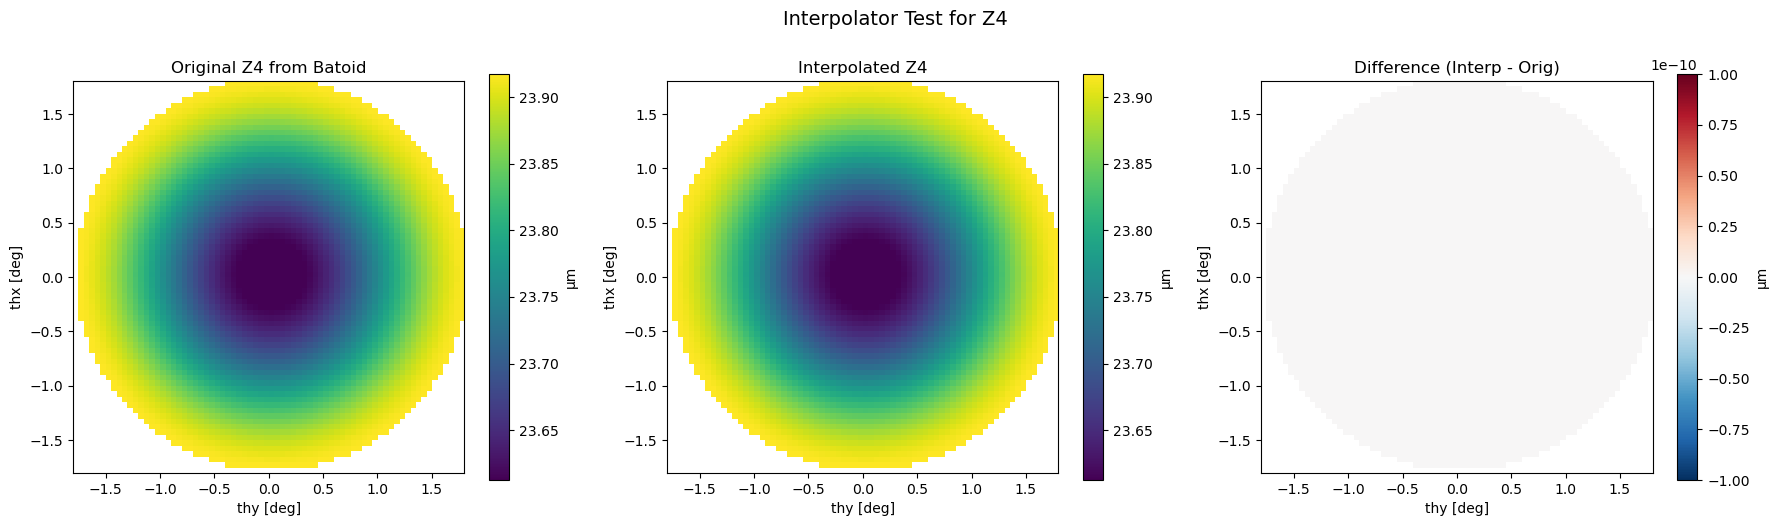


✓ Interpolator test PASSED


In [14]:
# Quick sanity check: test Z4 interpolator at model points
print("Testing interpolator with Z4 (defocus)...")

# The intrinsic model always has Z4-Z28 (25 terms, index 0 = Z4)
z_original = zkIntrinsics_model[0, :] * 1e6  # Z4 is row 0
z_interpolated = intrinsic_interpolators[4](X_model, Y_model) * 1e6
z_diff = z_interpolated - z_original

print(f"Original Z4 range: [{np.nanmin(z_original):.3f}, {np.nanmax(z_original):.3f}] μm")
print(f"Interpolated Z4 range: [{np.nanmin(z_interpolated):.3f}, {np.nanmax(z_interpolated):.3f}] μm")
print(f"Max absolute difference: {np.nanmax(np.abs(z_diff)):.6f} μm")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mean_orig, x_edges, y_edges, _ = binned_statistic_2d(
    X_model, Y_model, z_original, statistic='mean', bins=[xbins, ybins])
mean_interp, _, _, _ = binned_statistic_2d(
    X_model, Y_model, z_interpolated, statistic='mean', bins=[xbins, ybins])
mean_diff, _, _, _ = binned_statistic_2d(
    X_model, Y_model, z_diff, statistic='mean', bins=[xbins, ybins])

vmin, vmax = np.nanpercentile(z_original, [3., 97.])

im0 = axes[0].imshow(mean_orig.T, origin='lower',
    extent=[xbins[0], xbins[-1], ybins[0], ybins[-1]],
    cmap='viridis', interpolation='none', aspect='equal', vmin=vmin, vmax=vmax)
plt.colorbar(im0, ax=axes[0], label='μm')
axes[0].set_xlabel('thy [deg]'); axes[0].set_ylabel('thx [deg]')
axes[0].set_title('Original Z4 from Batoid')

im1 = axes[1].imshow(mean_interp.T, origin='lower',
    extent=[xbins[0], xbins[-1], ybins[0], ybins[-1]],
    cmap='viridis', interpolation='none', aspect='equal', vmin=vmin, vmax=vmax)
plt.colorbar(im1, ax=axes[1], label='μm')
axes[1].set_xlabel('thy [deg]'); axes[1].set_ylabel('thx [deg]')
axes[1].set_title('Interpolated Z4')

diff_lim = max(np.nanmax(np.abs(z_diff)), 1e-10)
im2 = axes[2].imshow(mean_diff.T, origin='lower',
    extent=[xbins[0], xbins[-1], ybins[0], ybins[-1]],
    cmap='RdBu_r', interpolation='none', aspect='equal', vmin=-diff_lim, vmax=diff_lim)
plt.colorbar(im2, ax=axes[2], label='μm')
axes[2].set_xlabel('thy [deg]'); axes[2].set_ylabel('thx [deg]')
axes[2].set_title('Difference (Interp - Orig)')

fig.suptitle('Interpolator Test for Z4', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

max_diff = np.nanmax(np.abs(z_diff))
if max_diff < 0.001:
    print("\n✓ Interpolator test PASSED")
else:
    print(f"\n⚠ Warning: large interpolator differences ({max_diff:.6f} μm)")

<a id='identify'></a>
## Identify Full Array Mode Data

Use ConsDB to identify FAM observations by program and image type.

In [ ]:
instrument = 'lsstcam'
visits_query = f'''
    SELECT
        v1.*,
        ql.physical_rotator_angle
    FROM
        cdb_{instrument}.visit1 v1
    LEFT JOIN
        cdb_{instrument}.visit1_quicklook ql
    ON v1.visit_id = ql.visit_id
    WHERE
        v1.day_obs >= {day_obs_min} AND v1.day_obs <= {day_obs_max}
'''
visits = client.query(visits_query).to_pandas()
print(f"Retrieved {len(visits)} visits between {day_obs_min} and {day_obs_max}")
print(f"physical_rotator_angle available for {visits['physical_rotator_angle'].notna().sum()} visits")

In [16]:
print_band_counts_by_day(visits, fam_programs, 'cwfs')

Total rows matching ['T278', 'T381', 'T492', 'T539', 'T614'] and img_type='cwfs': 961

Band counts by day_obs:
band_first  u   g    r    i   z   y
day_obs                            
20251023    0   0   48    0   0   0
20251024    0   0    0   11   0   0
20251026    0  48    0   48   0   0
20251027    0   2    0   36   0   0
20251028    0   0    0   11   0   0
20251030    0   0    0    4   0   0
20251031    0   0    6    0   0   0
20251101    0   0   28    0   0  24
20251102    0   0   16    0   0   0
20251103    0   0   10    0   0   0
20251104    0   0   30    2   0   0
20251105    0   0   50    4   0   0
20251107    0   0    4   56   2   0
20251108    0   0    0    4   0   0
20251109    0   0   52    4   0   0
20251110    0   0   37    4   0   0
20251111    0   0   26    4  26   0
20251112    0   0    0   32   0   0
20251113    0  34    0    4   0   0
20251114    0   0    0   34   0   0
20251115    0   0    3    4   2   0
20251116    0   2    2    0   0   0
20251117    0   0   28   

In [17]:
visit_pairs = get_visit_pairs_from_consdb(visits, fam_programs, img_type='cwfs')

print(f"\nFound {len(visit_pairs)} FAM cwfs visits")
unique_days = sorted(set([d for d, s in visit_pairs]))
print(f"Spanning {len(unique_days)} unique days: {unique_days[:5]}...{unique_days[-5:]}")

... and 2 more unpaired images

Found 477 FAM image pairs (keeping second of each pair)
Note: 7 unpaired images were skipped
Tip: Set verify_pairing=False to include all images without pair checking

Found 477 FAM cwfs visits
Spanning 59 unique days: [20251023, 20251024, 20251026, 20251027, 20251028]...[20251223, 20251224, 20251229, 20251230, 20251231]


<a id='rotator'></a>
## Rotator Angles

Determine the physical rotator angle for each visit using two sources:

1. **physical_rotator_angle** from ConsDB `visit1_quicklook` table (preferred)
2. **calc_rotator_angle** computed from MJD, RA, DEC, and sky_rotation via parallactic angle (fallback)

Flag visits with rotator angle exceeding the threshold.

In [ ]:
rotator_df = get_rotator_angles(
    visits, visit_pairs, threshold_deg=ROTATOR_ANGLE_THRESHOLD
)

<a id='extract'></a>
## Extract Zernike Measurements

Use Butler to extract Zernike wavefront measurements for the identified FAM observations.

In [19]:
print(f"Will query Butler collections: {fam_collections}")

Will query Butler collections: ['u/brycek/aos_fam_danish_step2/wep_v16_5_0/donut_viz_v3_2_3/20251020_20251231']


In [20]:
if Path(output_file).exists():
    print(f"Found existing file: {output_file}")
    aosTable = QTable.read(output_file)
    print(f"Loaded {len(aosTable)} rows from existing file")
    print("\nSkipping data extraction. Delete file to re-extract.")
else:
    print(f"No existing file found. Will extract data and save to: {output_file}")
    aosTable = None

No existing file found. Will extract data and save to: fam_zernikes_20251020_20251231.parquet


In [21]:
if aosTable is None:
    butler = None
    aosTable = get_zernikes_from_visits(butler, visit_pairs, fam_collections)
    if aosTable is None:
        print("\nNo data found!")
else:
    print("\nUsing previously loaded data")

Initializing Butler with collections: ['u/brycek/aos_fam_danish_step2/wep_v16_5_0/donut_viz_v3_2_3/20251020_20251231']

Extracting Zernikes for 477 visits...


 18%|█▊        | 84/477 [06:09<11:44,  1.79s/it]

DimensionValueError for day_obs=20251027, seq_num=78
DimensionValueError for day_obs=20251027, seq_num=81
DimensionValueError for day_obs=20251027, seq_num=84
DimensionValueError for day_obs=20251027, seq_num=87
DimensionValueError for day_obs=20251027, seq_num=90


 21%|██        | 101/477 [07:26<29:49,  4.76s/it]

DimensionValueError for day_obs=20251030, seq_num=30
DimensionValueError for day_obs=20251030, seq_num=53


...

DatasetNotFoundError: No data for day_obs=20251115, seq_num=53


 83%|████████▎ | 398/477 [29:51<04:34,  3.48s/it]

DatasetNotFoundError: No data for day_obs=20251209, seq_num=283


100%|██████████| 477/477 [36:21<00:00,  4.57s/it]



Extraction Summary:
  Total visits attempted: 477
  Successful extractions: 454
  Failed extractions:     23
  Total donut measurements: 1301100



<a id='model'></a>
## Add Model and Rotator Angles to Data

Use interpolation to get model intrinsic values at each donut position,
and add rotator angle columns from ConsDB and calculation.

In [ ]:
if aosTable is not None:
    aosTable = add_intrinsic_zernikes(aosTable, intrinsic_interpolators)
    print(f"\nTable now has {len(aosTable.columns)} columns")

    # Add rotator angles to the table (per visit)
    rot_dict = {}
    for _, r in rotator_df.iterrows():
        rot_dict[(r['day_obs'], r['seq_num'])] = r

    day_obs_arr = np.array(aosTable['day_obs'])
    seq_num_arr = np.array(aosTable['seq_num'])

    phys_rot = np.full(len(aosTable), np.nan)
    calc_rot = np.full(len(aosTable), np.nan)
    best_rot = np.full(len(aosTable), np.nan)
    rot_flag = np.zeros(len(aosTable), dtype=bool)

    for (dobs, snum), rot_info in rot_dict.items():
        mask = (day_obs_arr == dobs) & (seq_num_arr == snum)
        phys_rot[mask] = rot_info['physical_rotator_angle']
        calc_rot[mask] = rot_info['calc_rotator_angle']
        best_rot[mask] = rot_info['rotator_angle']
        rot_flag[mask] = rot_info['rotator_flagged']

    aosTable['physical_rotator_angle'] = phys_rot
    aosTable['calc_rotator_angle'] = calc_rot
    aosTable['rotator_angle'] = best_rot
    aosTable['rotator_flagged'] = rot_flag

    n_flagged = int(np.sum(rot_flag))
    print(f"\nAdded rotator angle columns")
    print(f"  Flagged measurements (|rotator| > {ROTATOR_ANGLE_THRESHOLD} deg): {n_flagged}")
    print(f"\nTable now has {len(aosTable.columns)} columns")

<a id='results'></a>
## Results Table and Data vs Model Comparison

In [23]:
if aosTable is not None:
    print("Table columns:")
    print(sorted(aosTable.columns))
    print(f"\nTable shape: {len(aosTable)} rows")
    print("\nFirst 5 rows:")
    print(aosTable[:5])

Table columns:
['centroid_x', 'centroid_x_extra', 'centroid_x_intra', 'centroid_y', 'centroid_y_extra', 'centroid_y_intra', 'coord_dec', 'coord_dec_extra', 'coord_dec_intra', 'coord_ra', 'coord_ra_extra', 'coord_ra_intra', 'day_obs', 'detector', 'extra_fpx', 'extra_fpy', 'intra_fpx', 'intra_fpy', 'matched_intra_extra', 'seq_num', 'th_N', 'th_N_extra', 'th_N_intra', 'th_W', 'th_W_extra', 'th_W_intra', 'thx_CCS', 'thx_CCS_extra', 'thx_CCS_intra', 'thx_OCS', 'thx_OCS_extra', 'thx_OCS_intra', 'thy_CCS', 'thy_CCS_extra', 'thy_CCS_intra', 'thy_OCS', 'thy_OCS_extra', 'thy_OCS_intra', 'used', 'zk_CCS', 'zk_CCS_mean', 'zk_NW', 'zk_OCS', 'zk_deviation_CCS', 'zk_deviation_NW', 'zk_deviation_OCS', 'zk_intrinsic', 'zk_intrinsic_CCS', 'zk_intrinsic_NW', 'zk_intrinsic_OCS', 'zk_residual']

Table shape: 1301100 rows

First 5 rows:
           zk_CCS            ...                   zk_residual                  
---------------------------- ... -----------------------------------------------
   0.035862

In [24]:
if aosTable is not None:
    print("\nMeasurements per day_obs:")
    day_counts = pd.DataFrame(aosTable['day_obs']).value_counts().sort_index()
    print(day_counts)


Measurements per day_obs:
day_obs 
20251023     69382
20251024     14617
20251026    125260
20251027     40069
20251028     15072
20251031      2907
20251101     67599
20251102     11215
20251104     45390
20251105     66314
20251107     91268
20251108      6028
20251109     80120
20251110     59074
20251111     83683
20251112     47114
20251113     55494
20251114     48083
20251115      8999
20251116      6185
20251117     39630
20251118      5938
20251119      5671
20251120      5748
20251121      8985
20251122      2938
20251123      2980
20251124      5698
20251125      5787
20251126      5722
20251127      2845
20251128      2964
20251129      2667
20251130      2108
20251201      3074
20251202      2788
20251203      2146
20251204      2848
20251206      2957
20251208      2977
20251209      5932
20251210      3093
20251211     45390
20251212      3012
20251214      2979
20251215      2970
20251216      3036
20251217      3067
20251218      3112
20251219     47814
20251220      

In [25]:
if aosTable is not None:
    aosTable.write(output_file, overwrite=True)
    print(f"\nSaved results to {output_file}")


Saved results to fam_zernikes_20251020_20251231.parquet


In [ ]:
if aosTable is not None:
    # Determine Zernike indices from the data
    zk_data = np.stack(aosTable[zk_col])
    nZk_data = zk_data.shape[1]
    iZs = infer_zernike_indices(nZk_data)
    iZidx = {iZ: i for i, iZ in enumerate(iZs)}

    # Scalar columns
    scalar_cols = [col for col in aosTable.columns
                   if not hasattr(aosTable[col][0], '__len__') or isinstance(aosTable[col][0], str)]
    df_display = aosTable[scalar_cols].to_pandas()

    pd.options.display.float_format = '{:.2f}'.format
    pd.options.display.max_columns = None
    pd.options.display.width = None

    print(f"\nTable Preview (first 10 rows):")
    print(f"Total rows: {len(aosTable)}, Total columns: {len(aosTable.columns)}")
    print(f"\nScalar columns:")
    print(df_display.head(10))

    # Show first 8 Zernike terms
    print("\n" + "="*80)
    print(f"Zernike Coefficients ({zk_col}, first 8 terms):")
    print("="*80)

    n_show = min(8, nZk_data)
    zk_display = pd.DataFrame(
        zk_data[:10, :n_show],
        columns=[f'Z{iZ}' for iZ in iZs[:n_show]]
    )
    zk_display.insert(0, 'day_obs', aosTable['day_obs'][:10])
    zk_display.insert(1, 'seq_num', aosTable['seq_num'][:10])
    print(zk_display)
    print(f"\nNote: Zernike values shown in microns")
    print(f"Full Zernike indices in table ({nZk_data} terms): {iZs}")

    pd.reset_option('display.float_format')

In [ ]:
# Z4 comparison: data vs model
if aosTable is not None:
    zk_data = np.stack(aosTable[zk_col])
    nZk_data = zk_data.shape[1]
    iZs = infer_zernike_indices(nZk_data)
    iZidx = {iZ: i for i, iZ in enumerate(iZs)}

    if 4 not in iZidx:
        print("Z4 not found in data Zernike indices!")
    else:
        z4_col = iZidx[4]
        Z4_data = zk_data[:, z4_col]
        Z4_model = np.array([row[z4_col] for row in aosTable['zk_intrinsic']]) * 1e6
        Z4_residual = Z4_data - Z4_model

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        axes[0].hist(Z4_data, bins=50, edgecolor='black', alpha=0.7)
        axes[0].set_xlabel('Z4 (Defocus) [um]'); axes[0].set_ylabel('Count')
        axes[0].set_title('Data'); axes[0].grid(alpha=0.3)

        axes[1].hist(Z4_model, bins=50, edgecolor='black', alpha=0.7, color='orange')
        axes[1].set_xlabel('Z4 (Defocus) [um]'); axes[1].set_ylabel('Count')
        axes[1].set_title('Model Intrinsic'); axes[1].grid(alpha=0.3)

        axes[2].hist(Z4_residual, bins=50, edgecolor='black', alpha=0.7, color='green')
        axes[2].set_xlabel('Z4 Residual [um]'); axes[2].set_ylabel('Count')
        axes[2].set_title('Data - Model'); axes[2].grid(alpha=0.3)

        plt.suptitle(f'Z4 Comparison ({COORD_SYS}): FAM Data ({day_obs_min}-{day_obs_max})', y=1.02)
        plt.tight_layout()
        plt.show()

        print(f"\nZ4 statistics (nm) [{COORD_SYS}]:")
        print(f"{'':12} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
        for label, arr in [('Data', Z4_data), ('Model', Z4_model), ('Residual', Z4_residual)]:
            print(f"{label:12} {np.mean(arr)*1e6:10.1f} {np.std(arr)*1e6:10.1f} "
                  f"{np.min(arr)*1e6:10.1f} {np.max(arr)*1e6:10.1f}")